In [25]:
import pickle

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("SAT_scores.csv")
df

,SAT Score,GPA
0,1600,4.0
1,1593,4.0
2,1587,4.0
3,1580,4.0
4,1573,4.0
...,...,...
176,427,0.0
177,420,0.0
178,413,0.0
179,407,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SAT Score  181 non-null    int64  
 1   GPA        181 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 3.0 KB


In [5]:
df.describe()

,SAT Score,GPA
count,181.000000,181.000000
mean,1000.000000,2.617901
std,349.293573,1.559243
min,400.000000,0.000000
25%,700.000000,1.390000
50%,1000.000000,3.370000
75%,1300.000000,3.970000
max,1600.000000,4.000000


In [6]:
#check if dataset any missing values
df.isna().sum()

SAT Score    0
GPA          0
dtype: int64

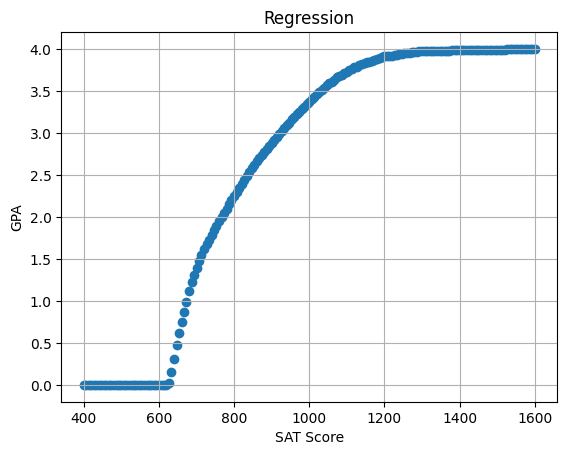

In [7]:
plt.scatter(df["SAT Score"],df["GPA"])
plt.xlabel("SAT Score")
plt.ylabel("GPA")
plt.title("Regression")
plt.grid()

In [8]:
#correaltion
df.corr()

,SAT Score,GPA
SAT Score,1.000000,0.923073
GPA,0.923073,1.000000


In [9]:
##split the data
x = df.drop('GPA',axis=1)
y = df['GPA']


In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=42)
x_test

,SAT Score
19,1473
42,1320
153,580
78,1080
145,633
15,1500
24,1440
68,1147
113,847
118,813


In [11]:
#train the model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['SAT Score']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.482
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [14]:
#model evalution using training dataset
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_absolute_percentage_error,root_mean_squared_error,r2_score

y_pred = model.predict(x_train)

#cal all metrics
mae = mean_absolute_error(y_train,y_pred)
mse = mean_squared_error(y_train,y_pred)
mape = mean_absolute_percentage_error(y_train,y_pred)
rmse = root_mean_squared_error(y_train,y_pred)
r2 = r2_score(y_train,y_pred)
print(f"mae :{mae} \nmse : {mse} \nmape : {mape} \nrmse : {rmse},r2 : {r2}")

mae :0.533451804460677 
mse : 0.36153359267220775 
mape : 543469331619381.9 
rmse : 0.6012766357278551,r2 : 0.8522119000726143


In [ ]:
#model evalution using testing dataset
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_absolute_percentage_error,root_mean_squared_error,r2_score
#pedict the y values for test dataset
y_pred = model.predict(x_test)

#cal all metrics
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
mape = mean_absolute_percentage_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print(f"mae :{mae} \nmse : {mse} \nmape : {mape} \nrmse : {rmse},r2 : {r2}")

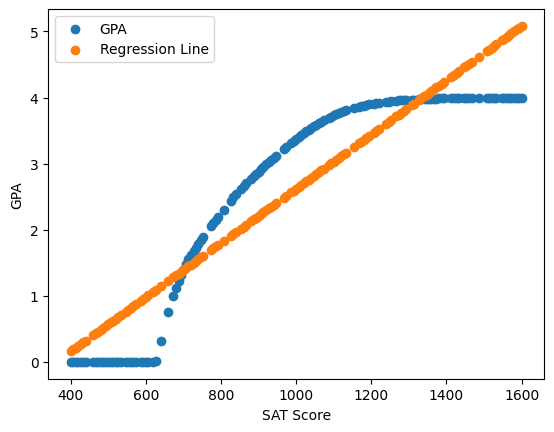

In [21]:
# Train result visualization.

y_pred = model.predict(x_train)
plt.scatter(x_train["SAT Score"],y_train,label='GPA')
plt.scatter(x_train["SAT Score"],y_pred,label='Regression Line')
plt.xlabel('SAT Score')
plt.ylabel('GPA')
plt.legend()

37
37


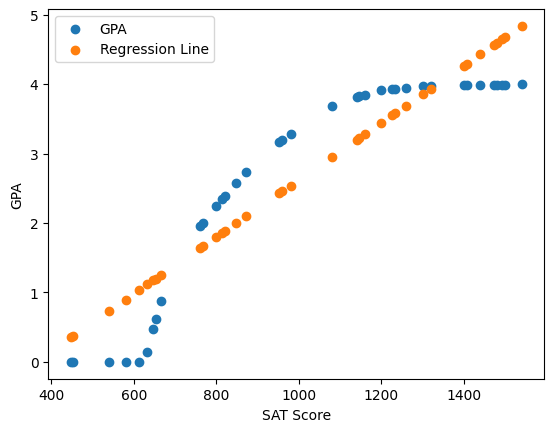

In [20]:
# TEST result visualization.

y_pred = model.predict(x_test)
print(len(y_test))
print(len(y_pred))
plt.scatter(x_test["SAT Score"],y_test,label='GPA')
plt.scatter(x_test["SAT Score"],y_pred,label='Regression Line')
plt.xlabel('SAT Score')
plt.ylabel('GPA')
plt.legend()

In [28]:
import pickle
with open("model.pkl", "wb") as file:
    pickle.dump(model,file)